LSTM - 国际航空乘客预测（改进版）
数据长度: 144个月
数据范围: 104 - 622

训练集: 92样本
测试集: 40样本

构建改进的LSTM模型...


d:\Anaconda\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 12, 32)         │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 12, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 16)             │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,633 (29.82 KB)

 Trainable params: 7,633 (29.82 KB)

 Non-trainable params: 0 (0.00 B)


开始训练...
Epoch 1/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 0.0368 - val_loss: 0.0552 - learning_rate: 0.0010
Epoch 2/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0155 - val_loss: 0.0274 - learning_rate: 0.0010
Epoch 3/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0126 - val_loss: 0.0455 - learning_rate: 0.0010
Epoch 4/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0121 - val_loss: 0.0297 - learning_rate: 0.0010
Epoch 5/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0095 - val_loss: 0.0239 - learning_rate: 0.0010
Epoch 6/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0078 - val_loss: 0.0220 - learning_rate: 0.0010
Epoch 7/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0071 - val_loss: 0.0199 - learning_rate: 0.0010
Epoch 8/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0089 - val_loss: 0.0204 - learning_rate: 0.0010
Epoch 9/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0087 - val_loss: 0.0203 - learning_rate: 0.0010
Epoch 10

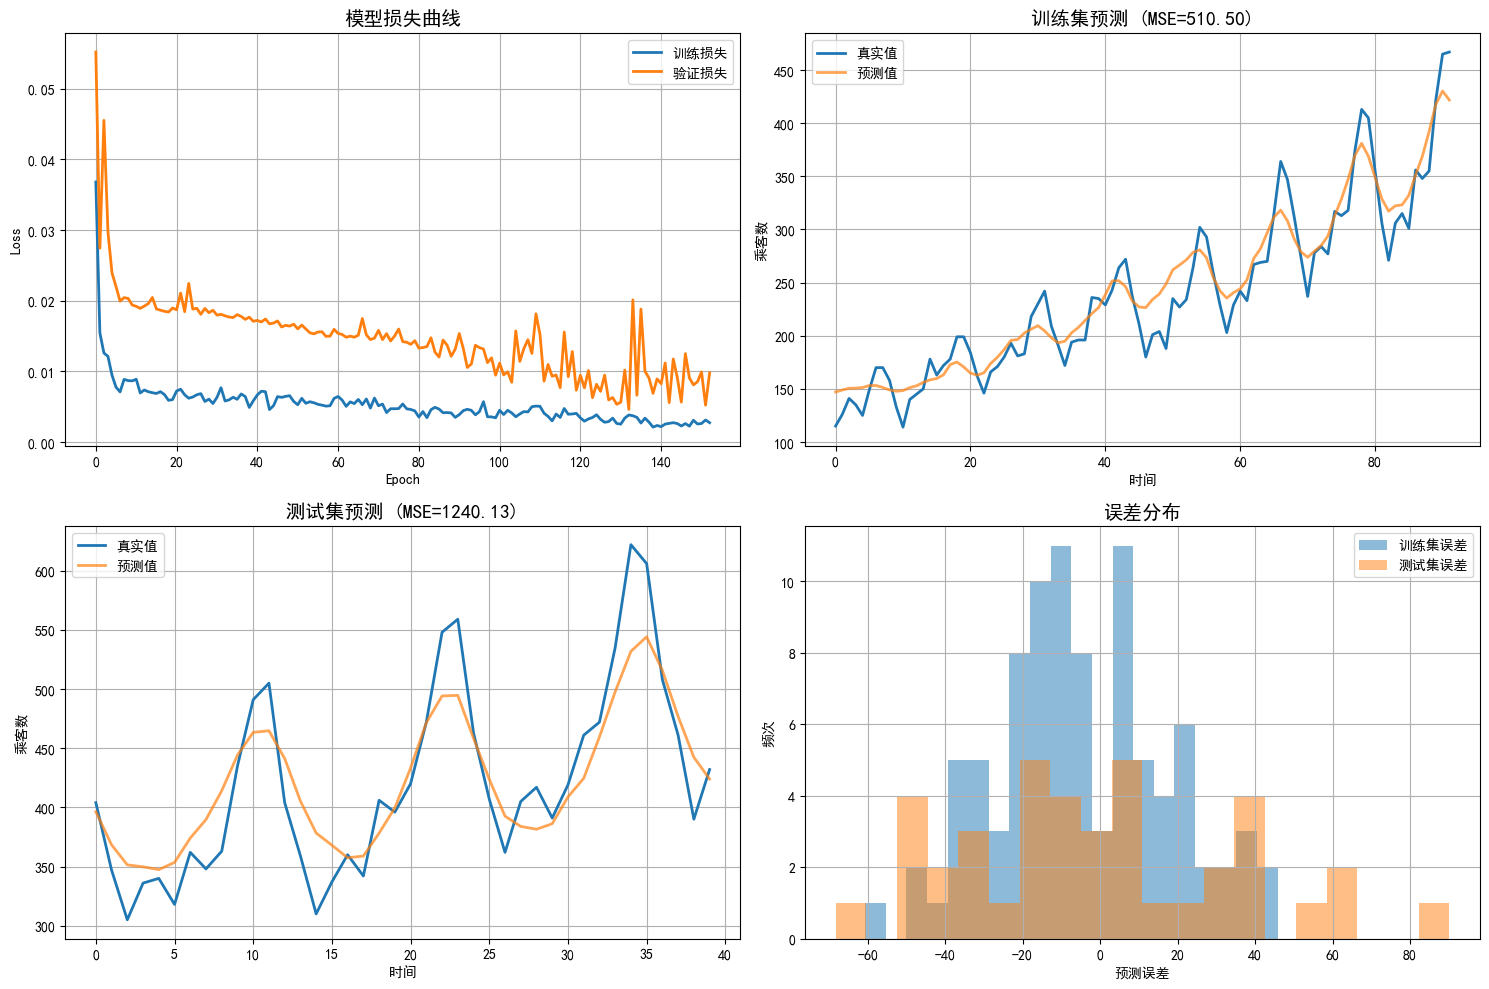


测试集前10个预测结果
序号	真实值	预测值	误差	相对误差
0	404	396	8	1.9%
1	347	368	21	6.2%
2	305	351	46	15.2%
3	336	350	14	4.1%
4	340	347	7	2.2%
5	318	353	35	11.2%
6	362	374	12	3.3%
7	348	390	42	12.0%
8	363	414	51	14.1%
9	435	444	9	2.1%

未来12个月预测
  第1个月: 406 乘客
  第2个月: 395 乘客
  第3个月: 408 乘客
  第4个月: 430 乘客
  第5个月: 458 乘客
  第6个月: 498 乘客
  第7个月: 534 乘客
  第8个月: 541 乘客
  第9个月: 518 乘客
  第10个月: 493 乘客
  第11个月: 464 乘客
  第12个月: 455 乘客


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# ================== 1. 加载数据 ==================
print("=" * 60)
print("LSTM - 国际航空乘客预测（改进版）")
print("=" * 60)

url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv'
df = pd.read_csv(url)
data = df['Passengers'].values.astype('float32')

print(f"数据长度: {len(data)}个月")
print(f"数据范围: {data.min():.0f} - {data.max():.0f}")

# ================== 2. 数据预处理 ==================
# 归一化
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data.reshape(-1, 1)).flatten()

def create_sequences(data, seq_length=12):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

seq_length = 12
X, y = create_sequences(data_scaled, seq_length)
X = X.reshape(X.shape[0], X.shape[1], 1)

# 划分训练集/测试集 (70%训练, 30%测试)
train_size = int(len(X) * 0.7)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print(f"\n训练集: {X_train.shape[0]}样本")
print(f"测试集: {X_test.shape[0]}样本")

# ================== 3. 构建改进的LSTM模型 ==================
print("\n构建改进的LSTM模型...")

model = Sequential([
    LSTM(32, return_sequences=True, input_shape=(seq_length, 1)),
    Dropout(0.3),
    LSTM(16, return_sequences=False),
    Dropout(0.3),
    Dense(8, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')
model.summary()

# ================== 4. 回调函数 ==================
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=10,
    min_lr=0.0001,
    verbose=1
)

# ================== 5. 训练模型 ==================
print("\n开始训练...")
history = model.fit(
    X_train, y_train,
    epochs=200,
    batch_size=8,  # 减小batch size
    validation_data=(X_test, y_test),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

print("训练完成！")

# ================== 6. 预测 ==================
train_pred = model.predict(X_train, verbose=0)
test_pred = model.predict(X_test, verbose=0)

# 反归一化
train_pred = scaler.inverse_transform(train_pred).flatten()
test_pred = scaler.inverse_transform(test_pred).flatten()
y_train_orig = scaler.inverse_transform(y_train.reshape(-1, 1)).flatten()
y_test_orig = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

# ================== 7. 评估 ==================
train_mse = mean_squared_error(y_train_orig, train_pred)
test_mse = mean_squared_error(y_test_orig, test_pred)
train_mae = np.mean(np.abs(y_train_orig - train_pred))
test_mae = np.mean(np.abs(y_test_orig - test_pred))

print("\n" + "=" * 60)
print("模型评估结果")
print("=" * 60)
print(f"训练集 MSE: {train_mse:.2f}")
print(f"测试集 MSE: {test_mse:.2f}")
print(f"训练集 MAE: {train_mae:.2f}")
print(f"测试集 MAE: {test_mae:.2f}")
print(f"测试集/训练集 MSE比: {test_mse/train_mse:.2f}")

# ================== 8. 可视化 ==================
plt.figure(figsize=(15, 10))

# 损失曲线
plt.subplot(2, 2, 1)
plt.plot(history.history['loss'], label='训练损失', linewidth=2)
plt.plot(history.history['val_loss'], label='验证损失', linewidth=2)
plt.title('模型损失曲线', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# 训练集预测
plt.subplot(2, 2, 2)
plt.plot(y_train_orig, label='真实值', linewidth=2)
plt.plot(train_pred, label='预测值', linewidth=2, alpha=0.7)
plt.title(f'训练集预测 (MSE={train_mse:.2f})', fontsize=14)
plt.xlabel('时间')
plt.ylabel('乘客数')
plt.legend()
plt.grid(True)

# 测试集预测
plt.subplot(2, 2, 3)
plt.plot(y_test_orig, label='真实值', linewidth=2)
plt.plot(test_pred, label='预测值', linewidth=2, alpha=0.7)
plt.title(f'测试集预测 (MSE={test_mse:.2f})', fontsize=14)
plt.xlabel('时间')
plt.ylabel('乘客数')
plt.legend()
plt.grid(True)

# 误差分布
plt.subplot(2, 2, 4)
train_errors = y_train_orig - train_pred
test_errors = y_test_orig - test_pred
plt.hist(train_errors, bins=20, alpha=0.5, label='训练集误差')
plt.hist(test_errors, bins=20, alpha=0.5, label='测试集误差')
plt.title('误差分布', fontsize=14)
plt.xlabel('预测误差')
plt.ylabel('频次')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# ================== 9. 显示预测结果 ==================
print("\n" + "=" * 60)
print("测试集前10个预测结果")
print("=" * 60)
print("序号\t真实值\t预测值\t误差\t相对误差")
for i in range(min(10, len(y_test_orig))):
    err = abs(y_test_orig[i] - test_pred[i])
    rel_err = err / y_test_orig[i] * 100
    print(f"{i}\t{y_test_orig[i]:.0f}\t{test_pred[i]:.0f}\t{err:.0f}\t{rel_err:.1f}%")

# ================== 10. 预测未来 ==================
# 用最后的数据预测未来12个月
last_sequence = data_scaled[-seq_length:].reshape(1, seq_length, 1)
future_pred = []

for i in range(12):
    next_pred = model.predict(last_sequence, verbose=0)[0, 0]
    future_pred.append(next_pred)
    last_sequence = np.roll(last_sequence, -1, axis=1)
    last_sequence[0, -1, 0] = next_pred

future_pred = scaler.inverse_transform(np.array(future_pred).reshape(-1, 1)).flatten()

print("\n" + "=" * 60)
print("未来12个月预测")
print("=" * 60)
for i, val in enumerate(future_pred):
    print(f"  第{i+1}个月: {val:.0f} 乘客")

In [2]:
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']  # 用黑体显示中文
plt.rcParams['axes.unicode_minus'] = False    # 正常显示负号